# Импортирование библиотек

In [23]:
import os                       # для работы с файлами
import random                   # для использования случайных чисел
from time import time           # для логирования времени
import re                       # для работы с регулярными выражениями
from zipfile import ZipFile   # для работы с .zip архивами

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Загрузка данных

In [25]:
# путь к архиву
archive_path = 'Data/ml-latest-small.zip'
# путь к конечной папке
data_path = 'Data/ml-latest-small'

# разархивируем данные
if not os.path.exists(data_path):
    with ZipFile(archive_path, 'r') as zip_f:
        zip_f.extractall('Data')

Создаем 4 датасета - для `ссылок`, ``названий фильмов``, ``рейтинга`` и ``тэгов``

In [26]:
# создадим словарь датафреймов для удобства
df_dict = {
    'links': pd.read_csv(data_path + '/links.csv'),         # датафрейм с ссылками
    'movies': pd.read_csv(data_path + '/movies.csv'),       # датафрейм с названиями фильмов
    'ratings': pd.read_csv(data_path + '/ratings.csv'),     # датафрейм с рейтингами
    'tags': pd.read_csv(data_path + '/tags.csv')            # датафрейм с тэгами
}
# --------------------------------------------------------------------------------

# логирование
for df_name, df in df_dict.items():
    print(f'Размер датасета "{df_name}": {df.shape}')

Размер датасета "links": (9742, 3)
Размер датасета "movies": (9742, 3)
Размер датасета "ratings": (100836, 4)
Размер датасета "tags": (3683, 4)


Визуализируем кол-во записей в датасетах

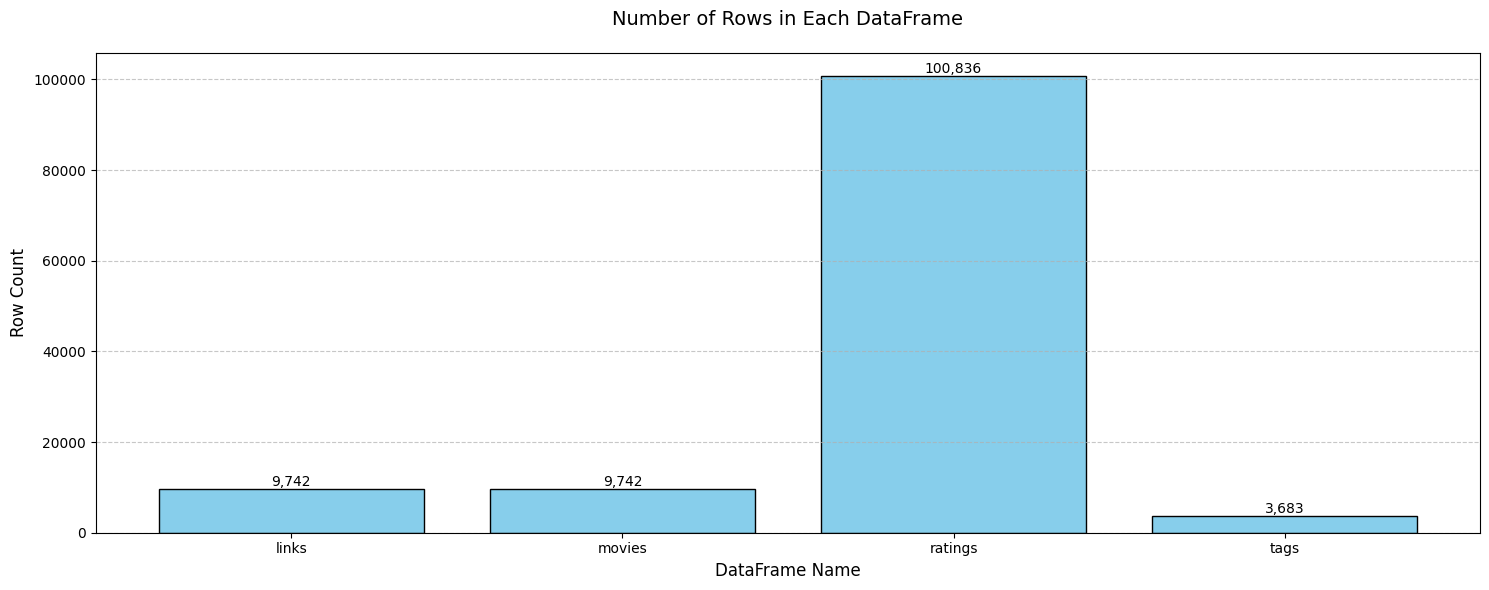

In [27]:
# Подготовка данных
names = list(df_dict.keys())  # Имена DataFrame как подписи
row_counts = [df.shape[0] for df in df_dict.values()]  # Количество строк

# Создание графика
plt.figure(figsize=(15, 6))

# Столбчатая диаграмма с улучшениями:
bars = plt.bar(
    x=names,  # Используем имена напрямую на оси X
    height=row_counts,
    color='skyblue',  # Более приятный цвет
    edgecolor='black'  # Границы столбцов
)

# Добавление значений поверх столбцов
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',  # Форматирование с разделителями тысяч
             ha='center', va='bottom')

# Настройка оформления
plt.title('Number of Rows in Each DataFrame', fontsize=14, pad=20)
plt.xlabel('DataFrame Name', fontsize=12)
plt.ylabel('Row Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Горизонтальные линии сетки

# Автоматическая подгонка layout для предотвращения обрезания
plt.tight_layout()
plt.show()

# Анализ и предобработка данных

**1. Анализ датасета с ссылками:**

In [28]:
df_dict['links'].head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [29]:
df_dict['links'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB


Видим, что в датасете нет пропущенных значений

In [30]:
# траффарет ссылки на фильм
base_url = 'https://movielens.org/movies/'

# возьмем слуяайный фильм из датасета, ID хранится в колонке moveid
print(f'Ссылка на случайный фильм: {base_url}{random.randint(1,df_dict["links"].shape[0])}')

Ссылка на случайный фильм: https://movielens.org/movies/7600


**2. Анализ датасета с названиями фильмов**

In [31]:
# создаем отдельную переменную для более удобной работы
movies = df_dict['movies']

In [32]:
print(movies.shape)
movies.head()

(9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Соберем все представленные жанры:

In [33]:
# инициализация списка
all_genres = []
# проходимся по каждой строчке
for i in range(movies['genres'].shape[0]):
    # разбиваем по жанрам строку
    example_genres = movies['genres'][i].split('|')
    # добавляем жанры в список
    for genre in example_genres:
        all_genres.append(genre)
    # удаляем повторения
    all_genres = list(set(all_genres))

# логирование
print(all_genres)
print('Всего различных жанров:', len(all_genres))

['Thriller', 'Action', '(no genres listed)', 'Comedy', 'Fantasy', 'Mystery', 'Adventure', 'Horror', 'Western', 'Film-Noir', 'Documentary', 'Children', 'War', 'Drama', 'Crime', 'Animation', 'IMAX', 'Musical', 'Romance', 'Sci-Fi']
Всего различных жанров: 20


**3. Анализ датасета с рейтингом**

Создам отдельную переменную

In [34]:
ratings = df_dict['ratings']

Выведу первые 5 записей

In [35]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [36]:
# создаем список уникальных ID пользоваетелей
user_ids = ratings['userId'].unique().tolist()
# логирование 
print(f'Всего пользователей оставивших отзыв: {len(user_ids)}')

Всего пользователей оставивших отзыв: 610


In [37]:
# создаем список уникальных ID пользоваетелей
movie_ids = ratings['movieId'].unique().tolist()
# логирование 
print(f'Всего фильмов: {len(movie_ids)}')

Всего фильмов: 9724


Для экономии памяти, приведу колонку с рейтингом к типу `float32`

In [38]:
ratings['rating'] = ratings['rating'].astype(np.float32)

In [39]:
# получаем минимальный и максимальный рейтинг
min_rating = min(ratings['rating'])
max_rating = max(ratings['rating'])

# логирование
print(f'Минимальный рейтинг: {min_rating}')
print(f'Максимальный рейтинг: {max_rating}')

Минимальный рейтинг: 0.5
Максимальный рейтинг: 5.0


Так как нейросети работают не с `ID` а с `числовыми представлениями` данных, я создам `кодировщик` и `декодировщик` для данных *(user и movies)*

In [40]:
# кодировка ID пользователей
user2user_encoded = {x: i for i, x in enumerate(user_ids)}      # из ID в число
user_encoded2user = {i: x for i, x in enumerate(user_ids)}      # из числа в ID
# вывод первых пяти пар
print('Кодировщик и декодировщик для пользователей:')
print(list(user2user_encoded.items())[:5])
print(list(user_encoded2user.items())[:5])

# кодировка ID фильмов
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}   # из ID в число
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)}   # из числа в ID
# вывод первых пяти пар
print('\nКодировщик и декодировщик для фильмов:')
print(list(movie2movie_encoded.items())[:5])
print(list(movie_encoded2movie.items())[:5])

Кодировщик и декодировщик для пользователей:
[(1, 0), (2, 1), (3, 2), (4, 3), (5, 4)]
[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)]

Кодировщик и декодировщик для фильмов:
[(1, 0), (3, 1), (6, 2), (47, 3), (50, 4)]
[(0, 1), (1, 3), (2, 6), (3, 47), (4, 50)]


Добавлю новые колонки в `DataFrame`, представляющие собой перекодированные `ID` пользователей и фильмов:

In [41]:
# пользователи
ratings['user'] = df['userId'].map(user2user_encoded)
# фильмы
ratings['movie'] = df['movieId'].map(movie2movie_encoded)

Ещё раз пересчитаю кол-во фильмов и пользователей, сохраняя в отдельную переменную:

In [42]:
num_users = len(user2user_encoded)
num_movies = len(movie2movie_encoded)

print(f'Кол-во пользователей: {num_users} \nКол-во фильмов: {num_movies}')


Кол-во пользователей: 610 
Кол-во фильмов: 9724


# Подготовка тренировочных и валидационных данных

Перемешиваю строки в датафрейме:

In [44]:
df = ratings.sample(frac=1, random_state=42)
df.shape

(100836, 6)

Обозначаю `x` *(features)*:

In [49]:
X = df[['user', 'movie']].values
X

array([[ nan,  nan],
       [ nan,  nan],
       [ nan,  nan],
       ...,
       [ nan,  nan],
       [423., 444.],
       [ nan,  nan]])

Обозначаю `y` *(target)* а также `нормализую` его в диапазон от `1 до 0` для более удобного обучения:

In [50]:
y = df['rating'].apply(
    lambda x: (x-min_rating) / (max_rating - min_rating)
).values
y

array([0.88888889, 0.55555556, 0.55555556, ..., 0.77777778, 0.55555556,
       1.        ])

Я буду использовать `90%` данных `для обучения` и `10%` `для валидации`

In [52]:
# получаю ID тренировочной выборки
train_ids = int(0.9 * df.shape[0])

# разбиваю датасет на выборки
X_train, X_val, y_train, y_val = (
    X[:train_ids],
    X[train_ids:],
    y[:train_ids],
    y[train_ids:]
)

# Архитектура модели

Я буду представлять пользователей и фильмы как `50-размерные вектора` *(эмбеддинги)*

In [53]:
EMBEDDING_SIZE = 50

In [ ]:
class RecommenderNet(nn.Module):
    # конструктор класса
    def __init__(self,
                 num_users: int,
                 num_movies: int,
                 embedding_size: int = EMBEDDING_SIZE,
                 **kwargs):
        super().__init__(**kwargs)
        # инициализация входных переменных
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = embedding_size
        
        # эмбеддинги пользователя
        self.user_embedding = nn.Embedding
        self.user_bias = nn.Embedding(num_users, 1)
        self.movie_embedding = nn.Embedding(
            num_movies,
            embedding_size,
            _weight = torch.randn(num_movies, embedding_size) * (2./embedding_size)**0.5
        )
        self.movie_bias = nn.Embedding(num_movies, 1)

    # функция для "шага"
    def forward(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        movie_vector = self.movie_embedding(inputs[:, 1])
        move_bias = self.movie_bias(inputs[:, 1])

        dot_user_movie = 